# Lab: Random Forests and XGBoost

*This notebook demonstrates a head-to-head comparison of two powerful ensemble models, Random Forest and XGBoost, on a regression task.*

---

## Stage 1: Business Understanding

Let's start by understanding the problem from a business perspective.

* **Scenario:** We are data scientists working for a real estate agency.
* **Business Objective:** To build a model that can accurately predict the median house value for any given district in California based on features of that district. This model can help agents price homes, identify undervalued areas, and advise clients.

---

## Stage 2: Analytic Approach
With the business problem defined, we select an analytic approach:

* **Problem Framing:** The goal is to predict a continuous numerical value (median house value). This is a **regression** problem.
* **Candidate Models:** In a real-world scenario, it makes sense to start with a multiple linear regression model and see how well it performs before trying more complex models. However, because this a lecture-specific lab, we will compare two state-of-the-art ensemble models:
    1. **Random Forest Regressor:** A **bagging** model that builds many decision trees in parallel and averages their predictions to reduce variance.
    2. **XGBoost Regressor:** A **boosting** model that builds trees sequentially, with each new tree correcting the errors of the previous one, to reduce bias.
* **Evaluation Metrics:** We will evaluate the models on two fronts:
    1. **Performance:** 
        * **Mean Squared Error (MSE):** The average of the squared differences between predicted and actual values. Lower is better.
        * **R-squared (R²):** The proportion of the variance in the target variable that is predictable from the features. A score closer to 1.0 is better.
    2. **Speed:**
        * **Training Time:** How long it takes to fit each model.
        * **Prediction Time:** How long it takes to generate predictions on the test set.

---

## Stage 3: Data Requirements
To build our model, we need a dataset containing features of California districts and their corresponding median house values. The `California Housing` dataset, available directly from scikit-learn, is perfect for this.

---

## Stage 4: Data Collection
We will load the dataset directly from scikit-learn's built-in datasets, just after we import necessary libraries and configure some settings.

In [1]:
# Import libraries
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use('fivethirtyeight')

In [3]:
# Load the California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target

print("California Housing dataset loaded successfully.")

California Housing dataset loaded successfully.



---

## Stage 5: Data Understanding (EDA)
Let's perform a quick check to understand the size and shape of our dataset.

In [12]:
n_observations, n_features = X.shape

print(f"- There are {n_observations} observations and {n_features} features in the dataset: \n {data.feature_names}. \n- The target variable is {data.target_names}")

- There are 20640 observations and 8 features in the dataset: 
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']. 
- The target variable is ['MedHouseVal']


> 📝 **Data Understanding Report:**
>
> *   The dataset contains **20.640** observations (districts) and **8** features (e.g., median income, average house age).
> *   This is a moderately sized dataset, suitable for a direct comparison of model performance without needing complex scaling or sampling strategies.

---

## Stage 6: Data Preparation
We will split the data into training and test sets. For tree-based models like Random Forest and XGBoost, feature scaling is not strictly necessary, so we will proceed without it to keep the focus on the model comparison.

In [13]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and test sets.")

Data successfully split into training and test sets.



---

## Stage 7: Modeling

We will initialize both the Random Forest and XGBoost models with the same number of estimators (`n_estimators=100`) for a fair comparison. We will then fit each model and time the training process.

In [23]:
# Initialize models
n_estimators = 100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
xgb = XGBRegressor(n_estimators=n_estimators, random_state=42)

# --- Fit models and measure training time --- #
# Measure training time for Random Forest
start_time_rf = time.time()
rf.fit(X_train, y_train)
end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf
print(f"Random Forest training completed in {rf_train_time:.3f} seconds.")

# Measure training time for XGBoost
start_time_xgb = time.time()
xgb.fit(X_train, y_train)
end_time_xgb = time.time()
xgb_train_time = end_time_xgb - start_time_xgb
print(f"XGBoost training completed in {xgb_train_time:.3f} seconds.")

Random Forest training completed in 8.328 seconds.
XGBoost training completed in 0.173 seconds.



---

## Stage 8: Evaluation
Now we evaluate our trained models on the held-back test set, measuring both prediction time and accuracy metrics.

In [24]:
# Measure prediction time for Random Forest
start_time_rf = time.time()
y_pred_rf = rf.predict(X_test)
end_time_rf = time.time()
rf_pred_time = end_time_rf - start_time_rf

# Measure prediction time for XGBoost
start_time_xgb = time.time()
y_pred_xgb = xgb.predict(X_test)
end_time_xgb = time.time()
xgb_pred_time = end_time_xgb - end_time_xgb

In [25]:
# Calculate MSR and R^2 values
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [27]:
# Print the MSE and R^2 values
print("\n ========== Model Performance ===========")
print(f"Random Forest:  MSE = {mse_rf:.4f}, R² = {r2_rf:.4f}")
print(f"      XGBoost:  MSE = {mse_xgb:.4f}, R² = {r2_xgb:.4f}")

# Print the timings for each model
print("\n ============== Model Speed =============")
print(f"Random Forest:  Training Time = {rf_train_time:.3f} s, Prediction Time = {rf_pred_time:.3f} s")
print(f"      XGBoost:  Training Time = {xgb_train_time:.3f} s, Prediction Time = {xgb_pred_time:.3f} s")


 ========== Model Performance ===========
Random Forest:  MSE = 0.2557, R² = 0.8049
      XGBoost:  MSE = 0.2226, R² = 0.8301

 ============== Model Speed =============
Random Forest:  Training Time = 8.328 s, Prediction Time = 0.128 s
      XGBoost:  Training Time = 0.173 s, Prediction Time = 0.000 s


### Visualizing the Results
A scatter plot of predicted vs. actual values is a great way to visually assess a regression model's performance. A perfect model would have all points lying on the diagonal line.

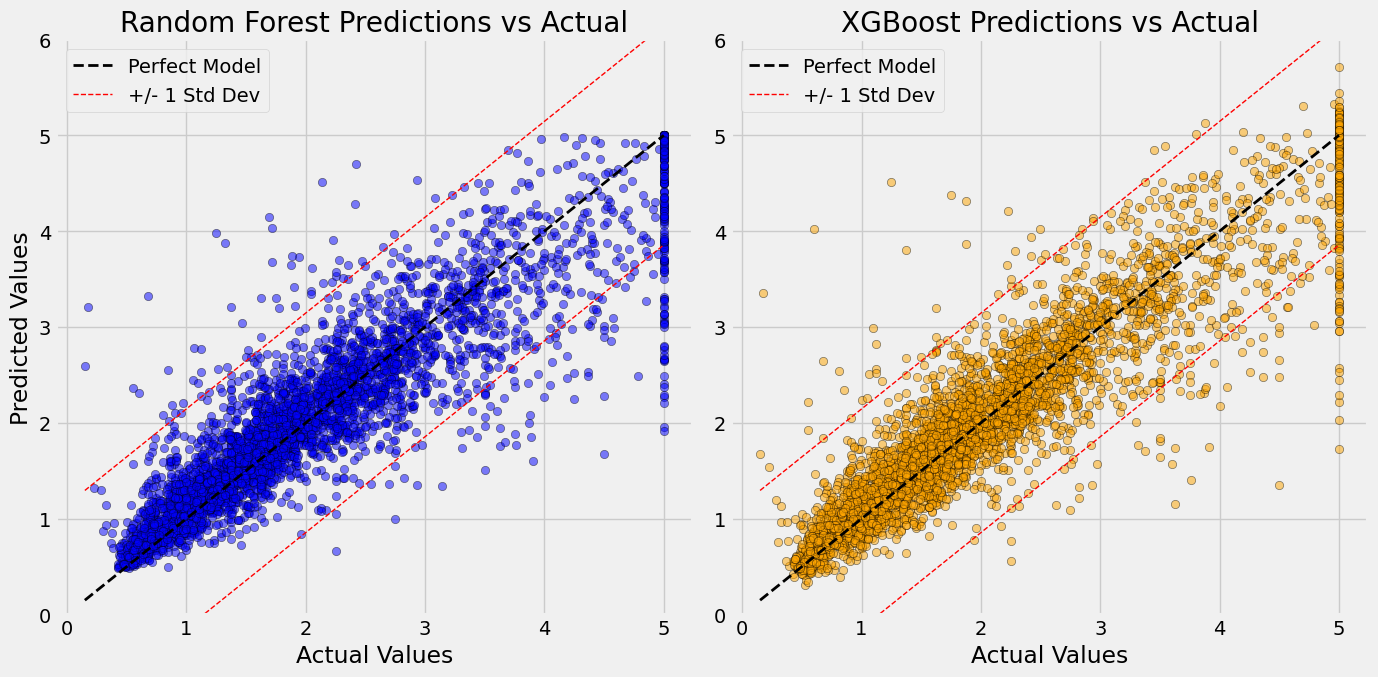

In [42]:
# Calculate the standard deviation of the test data
std_y = np.std(y_test)

plt.figure(figsize=(14, 7))

# Random Forest Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="blue", ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1)
plt.ylim(0, 6)
plt.title("Random Forest Predictions vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

# XGBoost Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color="orange", ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_y, y_test.max() + std_y], 'r--', lw=1, label="+/- 1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_y, y_test.max() - std_y], 'r--', lw=1)
plt.ylim(0, 6)
plt.title("XGBoost Predictions vs Actual")
plt.xlabel("Actual Values")
plt.legend()

plt.tight_layout()
plt.show()



---

## Conclusion

| Metric | Random Forest | XGBoost | Winner |
| :--- | :--- | :--- | :--- |
| **R² Score** | ~0.805 | **~0.830** | **XGBoost** |
| **MSE** | ~0.256 | **~0.223** | **XGBoost** |
| **Training Time** | Slow | **Fast** | **XGBoost** |
| **Prediction Time** | Slow | **Fast** | **XGBoost** |

### 📝 Final Analysis
Across the board, **XGBoost is the clear winner** on this dataset.

* **Performance:** It achieved a higher R² score and a lower MSE, indicating it is the more accurate model.
* **Speed:** It was significantly faster in both training and prediction, which is a major advantage, especially as datasets grow larger.

The scatter plots visually confirm these results, showing that the predictions from both models cluster tightly around the "perfect model" line, but the XGBoost points are slightly tighter. This lab clearly demonstrates why XGBoost has become a dominant algorithm in applied machine learning and data science competitions.

---

**Next:** [Clustering Strategies and Real-World Applications](../04_building_unsupervised_learning_models/01_clustering_strategies_and_real-world_applications.md)